In [1]:
import numpy as np
from IPython.display import Image


# FEniCSx Navier-Stokes (NS) Solver
---
Technical solver details:
- Taylor-Hood elements for velocity and pressure
- BDF2 time-stepping scheme

Goals for this solver:
- 2D Exact Taylor-Green vortex
    - Compare norms
- 3D Exact solution Steinmann vortex problem
    - Compare norms
- 2D DFG benchmark problem
    - Does solver preform as expected?
- Simple anulus spinal geometry

## Taylor-Green Vortex Problem [[1]](https://en.wikipedia.org/wiki/Taylor%E2%80%93Green_vortex)

The original work describes a 3 dimensional flow. It's defined by the three velocity components $\boldsymbol v = (u,v,w)$ at time $t = 0$ governed bt the three equations:

$$
\begin{align*}
u = A \cos(ax)\sin(by)\sin(cz), \\
v = B \sin(ax)\cos(by)\sin(cz), \\
w = C \sin(ax)\sin(by)\cos(cz). 
\end{align*}
$$

The continuity eq. $\nabla \cdot \boldsymbol v = 0$ determines that $Aa + Bb + Cc = 0$.

An exact solution is known in two spatial dimensions, and it's what we will try to replicate with the FEniCSx NS solver.

### The Incompressible NS eq.
The incompressible Navier-Stokes equations are given by:

$$
\begin{align*}
&\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0, \\
&\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = - \frac 1 \rho \frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right), \\
&\frac{\partial v}{\partial t} + u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = - \frac 1 \rho \frac{\partial p}{\partial y} + \nu \left( \frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2} \right).
\end{align*}
$$

The first equation is the continuity equation. The two under are the momentum equations.


### Taylor-Green Vortex Exact Solution

In an infinite domain, the doubly periodic solution is given by 

$$
\begin{align*}
u = U_0 \sin(kx)\cos(ky)F(t), & \quad v = -U_0 \cos(kx)\sin(ky)F(t), \\
F(t)&=e^{-\nu k^2t}
\end{align*}
$$

Here $U_0$ is the maximum velocity in the flow field, $k$ is the inverse length scale, $\nu$ is the kinematic viscosity. From Taylor and Green we know that with $A=a=b=1$ we get this exact solution. Further we can expand the exponential as a Taylor series, $F(t) = 1 - 2\nu k^2t + \mathcal O(t^2)$. The pressure field $p$ is obtained by substituting the velocity solution in to the momentum equations, 

$$
\begin{align*}
p = \frac{\rho U_0^2}{4}(\cos(2k x)+ \cos (2 k y)) F(t)^2
\end{align*}
$$

With $\rho$ being the fluid density.

The stream function of the Taylor-Green vortex is given by, that satisfies $\boldsymbol v = \nabla \times \psi$,

$$
\begin{align*}
\psi = U_0 \sin(kx)\sin(ky)F(t) \boldsymbol{\hat z}.
\end{align*}
$$

With the similar vorticity given by, that also satisfies $\boldsymbol \omega = \nabla \times \boldsymbol v$,

$$
\begin{align*}
\omega = 2U_0\sin(kx)\sin(ky)F(t)\boldsymbol{\hat z}.   
\end{align*}
$$
---

$$
\boldsymbol{u}(x,y,t) =
\begin{pmatrix}
u(x,y,t)\
v(x,y,t)
\end{pmatrix}
$$

$$

p(x,y,t) =
\frac{\rho U_0^2}{4}
\left[
\cos(2kx)+\cos(2ky)
\right]
e^{-2\nu k^2t}.
$$

$$
\frac{p}{\rho} =
\frac{U_0^2}{4}
\left[
\cos(2kx)+\cos(2ky)
\right]
e^{-2\nu k^2t}.
$$


$$
\boldsymbol{f}=\boldsymbol{0}.
$$

$$
\int_\Omega p,dx=0.
$$

In [2]:
from mpi4py import MPI
from dolfinx import mesh, fem
### Taylor Green (TG) exact solution functions

F = lambda t : np.exp(-nu*k**2*t)

u_exact = lambda x, t, U_0: U_0 * np.sin(k*x[0]) * np.cos(k*x[1]) * F(t)
v_exact = lambda x, t, U_0: -U_0 * np.cos(k*x[0]) * np.sin(k*x[1]) * F(t)
velocities_exact = lambda x, t, U_0: np.array([u_exact(x, t, U_0), v_exact(x, t, U_0)])

p_exact = lambda x, t, U_0: rho * U_0**2 / 4 * (np.cos(2*k*x[0]) + np.cos(2*k*x[1])) * F(t)**2

make_TG_domain = lambda N : mesh.create_unit_square(MPI.COMM_WORLD, N, N, mesh.CellType.quadrilateral) 

In [3]:
### TG parameters and initialization

# Fluid parameters
nu = 0.01
k = 2.0 * np.pi # To guarantee periodicity on the unit square, we choose k = 2 * pi
rho = 1.0 
U_0 = 1.0

# Grid 
N = 32

# Time
t_0 = 0.0
T = 10
dx = 0.1


# Initialization
domain = make_TG_domain(N)

Q = fem.functionspace(domain, ("Lagrange", 1))
V = fem.functionspace(domain, ("Lagrange", 2, (domain.geometry.dim,)))

p_exact_function = fem.Function(Q)
p_exact_function.interpolate(lambda x: p_exact(x, t_0, U_0))

u_exact_function = fem.Function(V)
u_exact_function.interpolate(lambda x: velocities_exact(x, t_0, U_0))

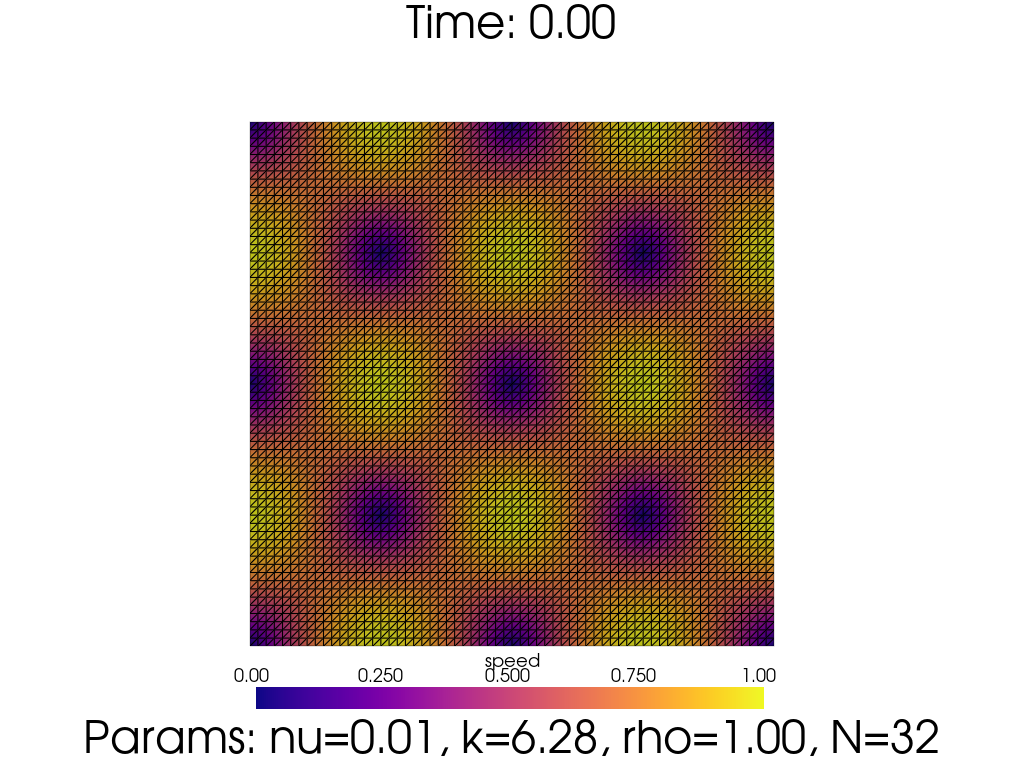

In [4]:
from dolfinx import plot
import pyvista as pv

# Use the velocity function space so the mesh points match the P2 degrees of freedom.
topology, cell_types, geometry = plot.vtk_mesh(u_exact_function.function_space)

grid = pv.UnstructuredGrid(topology, cell_types, geometry)

velocity = u_exact_function.x.array.real.reshape((geometry.shape[0], domain.geometry.dim))
speed = np.linalg.norm(velocity, axis=1)

grid["velocity"] = velocity
grid["speed"] = speed

plotter = pv.Plotter()

sargs = dict(
    vertical=False,
    width=0.5,             # Takes up 50% of the horizontal screen
    position_x=0.25,       # Starts at 25% from the left (perfectly centered)
    position_y=0.075,       # Slightly offset from the absolute bottom edge
)

plotter.add_mesh(
    grid,
    scalars="speed",
    show_edges=True,
    cmap="plasma",
    clim=(0.0, U_0),
    scalar_bar_args=sargs
)

plotter.add_text(f"Time: {t_0:.2f}", name="time_label", position="upper_edge")
plotter.add_text(f"Params: nu={nu:.2f}, k={k:.2f}, rho={rho:.2f}, N={N}", name="parameter_label", position="lower_edge")

plotter.view_xy()
plotter.screenshot("taylor_green.png")
plotter.close()

Image(filename="taylor_green.png")


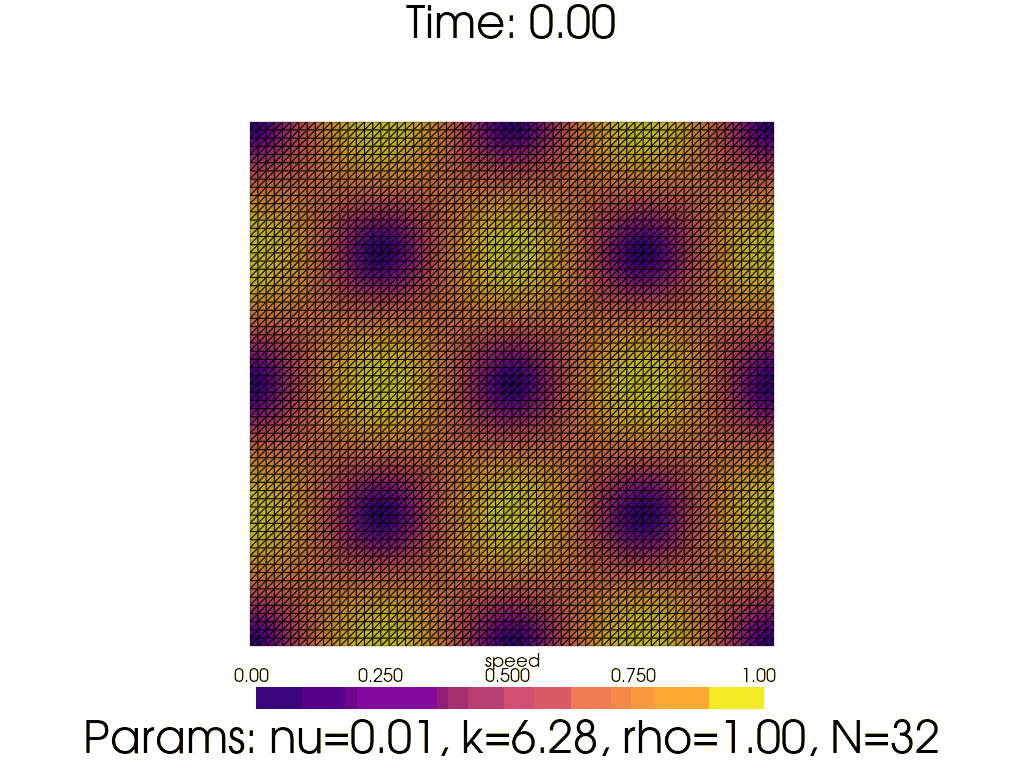

In [5]:
def update_exact_velocity(t):
    u_exact_function.interpolate(lambda x: velocities_exact(x, t, U_0))

gif = pv.Plotter()



gif.add_mesh(
    grid,
    scalars="speed",
    show_edges=True,
    cmap="plasma",
    clim=(0.0, U_0),
    scalar_bar_args=sargs
)

gif.enable_2d_style()
gif.view_xy()

gif.open_gif("taylor_green.gif")
T = 7
dx = 0.25

for t in np.arange(t_0, T, dx):
    update_exact_velocity(t)
    velocity = u_exact_function.x.array.real.reshape((geometry.shape[0], domain.geometry.dim))
    speed = np.linalg.norm(velocity, axis=1)
    grid["speed"] = speed
    gif.add_text(f"Time: {t:.2f}", name="time_label", position="upper_edge")
    gif.add_text(f"Params: nu={nu:.2f}, k={k:.2f}, rho={rho:.2f}, N={N}", name="parameter_label", position="lower_edge")

    gif.write_frame()
gif.close()
Image(filename="taylor_green.gif")


In [6]:
from abc import ABC, abstractmethod
import ufl
from petsc4py import PETSc
from dolfinx import fem
from dolfinx.fem.petsc import LinearProblem

def t_h_space(msh):
    gdim = msh.geometry.dim
    V = fem.functionspace(msh, ("Lagrange", 2, (gdim,))) # P2
    Q = fem.functionspace(msh, ("Lagrange", 1)) # P1
    return V, Q

def DirectLU():
    pass


class Solver(ABC):
    def __init__(self, case, params, preconditioner=None, observers=()):
        self.case, self.params = case, params
        self.pc = preconditioner or self.default_preconditioner()
        self.observers = list(observers)

    def default_preconditioner(self):
        return DirectLU()

    def solve(self):
        self.ksp.solve(self.b, self.x)

class SteadyState(Solver):
    pass

class TimeDependence(Solver): 
    def __init__(self, case, params, scheme, observers=()):
        super().__init__(case, params, observers)
        self.t, self.dt, self.T = self.params.t, self.params.dt, self.params.T
        self.scheme = scheme

    def run(self) :
        self.setup()
        while self.t < self.T:
            self.t += self.dt
            self.update_boundary_data(self.t)
            self.assemble_step()
            self.solve()
            self.advance_history()
            for obs in self.observers: obs.on_step(self) 

    @abstractmethod
    def setup(self):
        pass

    @abstractmethod 
    def update_boundary_data(self, t):
        pass

    @abstractmethod
    def assemble_step(self):
        pass

    @abstractmethod
    def solve(self):
        pass

    @abstractmethod
    def advance_history(self):
        pass    

In [7]:
class SteadyNavierStokesSolver(SteadyState):
    pass

class NavierStokesSolver(TimeDependence):
    def setup(self):
        self.V, self.Q = t_h_space(self.case.mesh)
        self.u_h = fem.Function(self.V)
        self.u_n = fem.Function(self.V)
        self.u_nm = fem.Function(self.V)

        self.p_h = fem.Function(self.Q)
        self.p_n = fem.Function(self.Q)
        # Not needed? self.p_nm = fem.Function(self.Q)

        rho_c, mu_c, dt_c, gamma_c, beta_c = self.params

        

    def update_boundary_data(self, t):
        self.case.update_boundary_data(t)

    def assemble_step(self):
        u, v = ufl.TrialFunction(self.V), ufl.TestFunction(self.V)
        p, q = ufl.TrialFunction(self.Q), ufl.TestFunction(self.Q)

        rho_c, mu_c, dt_c, gamma_c, beta_c, u_n, u_nm, n, ds_open = self.params

In [8]:
class BoundaryCondition(ABC):
    @abstractmethod
    def apply(self, W, t):
        pass

class Strong(BoundaryCondition):
    def __init__(self, W, marker, u_of_t):
        pass

class Weak(BoundaryCondition):
    @abstractmethod
    def bilinear_form(self, W, t):
        pass
    @abstractmethod
    def linear_form(self, W, t):
        pass

    def update(self, W, t):
        pass

class DirichletVelocity(Strong):
    def __init__(self, W, face_tags, marker, u_of_t):
        V, _ = W.sub(0).collapse()
        self.g, self.u_of_t = fem.Function(V), u_of_t
        fdim = W.mesh.topology.dim - 1
        dofs = fem.locate_dofs_topological((W.sub(0),V), fdim, face_tags.find(marker))
        self.bc = fem.dirichletbc(self.g, dofs, W.sub(0))

    def update(self, t):
        self.g.interpolate(self.u_of_t(t))

In [9]:
def make_TG_mesh(N, L):
    msh = mesh.create_rectangle(MPI.COMM_WORLD, [np.array([0, 0]), np.array([L, L])], [N, N], mesh.CellType.quadrilateral)
    fdim = msh.topology.dim - 1

    # Tags boundary facet with marker 1, using locate_entities_boundary and meshtags
    def boundary(x):
        return np.isclose(x[0], 0) | np.isclose(x[0], L) | np.isclose(x[1], 0) | np.isclose(x[1], L)
    
    facet_indices = mesh.locate_entities_boundary(msh, fdim, boundary)
    facet_tags = mesh.meshtags(msh, fdim, facet_indices, 1)

    return msh, facet_tags


class Case(ABC):
    def __init__(self, physical_params):
        self.physical_params = physical_params

    @abstractmethod
    def create_mesh(self):  ...            # returns (mesh, facet_tags)

    @abstractmethod
    def boundary_conditions(self, W): ...

    def body_force(self, x, t):  return None
    def initial_condition(self, t): ...    # callable for interpolation
    pressure_nullspace: bool = False

class TaylorGreenCase(Case):
    pressure_nullspace = True

    def __init__(self, N, physical_params):
        super().__init__(physical_params)
        self.N = N
        self.L = 2 * np.pi / self.physical_params.wave_number # Self.L not implemented yet
        self.mesh, self.face_tags = make_TG_mesh(self.N, self.L)

    def create_mesh(self):
        return make_TG_mesh(self.N, self.L) #self.L not implemented yet, and it should also return facet_tags

    def u_exact(self, t):
        U0, nu, k = self.physical_params.U0, self.physical_params.nu, self.physical_params.wave
        F = np.exp(-nu*k**2*t)

        return lambda x: np.vstack([U0 * np.sin(k*x[0]) * np.cos(k*x[1]) * F, 
                                    -U0 * np.cos(k*x[0]) * np.sin(k*x[1]) * F])

    def p_exact(self, t):
        U0, nu, k = self.physical_params.U0, self.physical_params.nu, self.physical_params.wave
        F = np.exp(-nu*k**2*t)

        return lambda x: rho * U0**2 / 4 * (np.cos(2*k*x[0]) + np.cos(2*k*x[1])) * F**2

    def boundary_conditions(self, W):
        return [DirichletVelocity(W, self.face_tags, marker=1, u_of_t=self.u_exact)]

    def initial_condition(self, t):
        k, U0, nu = self.physical_params.wave_number, self.physical_params.U0, self.physical_params.nu
        return lambda x: velocities_exact(x, t, U0, nu, k)



In [10]:
from dataclasses import dataclass

@dataclass(frozen=True)
class NumericalParameters:
        t0: float
        T: float
        dt: float

@dataclass(frozen=True)
class PhysicalParameters:
        nu: float
        rho: float
        wave_number: float
        U0: float

        @property
        def mu(self):
            return self.nu * self.rho

phys_params = PhysicalParameters(nu=0.01, rho=1.0, U0=1.0, wave_number=2.0*np.pi)
num_params = NumericalParameters(t0=0.0, T=10, dt=0.1)

case = TaylorGreenCase(N=32, physical_params=phys_params)



In [11]:
# Pressure-driven Poiseuille flow on the unit square.

import ufl
from petsc4py import PETSc
from dolfinx import fem
from dolfinx.fem.petsc import LinearProblem

def domain_n_disc(msh) :
    gdim = msh.geometry.dim

    V = fem.functionspace(msh, ("Lagrange", 2, (gdim,))) # P2
    Q = fem.functionspace(msh, ("Lagrange", 1)) # P1
    u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
    p, q = ufl.TrialFunction(Q), ufl.TestFunction(Q)

    u_h = fem.Function(V, name="velocity")
    p_h = fem.Function(Q, name="pressure")
    u_n = fem.Function(V, name="u_n") # u^{n}
    u_nm = fem.Function(V, name="u_nm") # u^{n-1}

    return V, Q, u, v, p, q, u_h, p_h, u_n, u_nm

def solve_ns(msh, rho=1.0, mu=1.0, dt=0.02, t_end=10.0, outlet=None, gamma=0.0, beta=1.0):

    V, Q, u, v, p, q, u_h, p_h, u_n, u_nm = domain_n_disc(msh)

    rho_c = fem.Constant(msh, PETSc.ScalarType(rho))
    mu_c = fem.Constant(msh, PETSc.ScalarType(mu))
    dt_c = fem.Constant(msh, PETSc.ScalarType(dt))
    gamma_c = fem.Constant(msh, PETSc.ScalarType(gamma))
    beta_c = fem.Constant(msh, 1.0)

    dx = ufl.Measure("dx", msh, metadata={"quadrature_degree": 4})
    eps = lambda z: ufl.sym(ufl.nabla_grad(z))
    
    u_ns = 2 * u_n - u_nm
    convection = 0.5 * rho_c * (ufl.inner(ufl.dot(ufl.dot(u), u_ns), v) 
                                - ufl.inner(ufl.dot(ufl.dot(v), u_ns), u))

    a00 = (1.5 *rho_c / dt_c * ufl.inner(u, v) * dx
            + 2 * mu_c * ufl.inner(eps(u), eps(v)) * dx
            + gamma_c * ufl.div(u) * ufl.div(v) * dx
            + convection * dx
            + 0.5 * rho_c / dt_c * ufl.dot(u_nm, v) * ufl.inner(u, v) * ds_open
            - 0.5 * beta_c * rho_c * (-(ufl.dot(u_ns, n))) * ufl.inner(u, v) * ds_open)

    a01 = -p * ufl.div(v) * dx

    a10 = -q * ufl.div(u) * dx


    L0 = rho_c / (2 * dt_c) * ufl.inner(4*u_n - u_nm, v) * dx 
    
    L1 = ufl.ZeroBaseForm((q,))

    a = fem.form([[a00, a01], [a10, None]])
    L = fem.form([L0, L1])                                      


    problem = LinearProblem(
        a, L, u=[u_h, p_h], bcs=bcs,
        petsc_options_prefix="ns_",
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    )

    num_steps = int(round(t_end / dt))
    history = {"t": [], "change": []}
    t = 0.0
    for step in range(1, num_steps + 1):
        t = step * dt
        problem.solve()
        change = np.linalg.norm(u_h.x.array - u_n.x.array)
        history["t"].append(t)
        history["change"].append(change)
        u_n.x.array[:] = u_h.x.array

    return u_h, p_h, history


In [12]:
from mpi4py import MPI
from dolfinx.mesh import create_unit_square
from dolfinx.plot import vtk_mesh

#msh = create_unit_square(MPI.COMM_WORLD, 10, 10)
#u_h, p_h, history = solve_ns(msh, rho=1.0, mu=1.0, dt=0.005, t_end=10.0)
#print(f"Solved {len(history['t'])} time steps; t = {history['t'][-1]:.2f}")


In [13]:
"""# Convert the computed P2 velocity field to a VTK grid.
topology, cell_types, geometry = vtk_mesh(u_h.function_space)
gdim = msh.geometry.dim
velocity = u_h.x.array.real.reshape((geometry.shape[0], gdim))
values = np.zeros((geometry.shape[0], 3), dtype=np.float64)
values[:, :gdim] = velocity

function_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
function_grid["u"] = values
function_grid["speed"] = np.linalg.norm(velocity, axis=1)
glyphs = function_grid.glyph(orient="u", factor=0.12, tolerance=0.02)

plotter = pyvista.Plotter()
plotter.add_mesh(
    function_grid,
    scalars="speed",
    cmap="viridis",
    show_edges=True,
    scalar_bar_args={"title": "Velocity magnitude"},
)
plotter.add_mesh(glyphs, color="white")
plotter.view_xy()
plotter.add_title("Pressure-driven channel velocity")

if pyvista.OFF_SCREEN:
    plotter.screenshot("channel_velocity.png")
else:
    plotter.show()"""


'# Convert the computed P2 velocity field to a VTK grid.\ntopology, cell_types, geometry = vtk_mesh(u_h.function_space)\ngdim = msh.geometry.dim\nvelocity = u_h.x.array.real.reshape((geometry.shape[0], gdim))\nvalues = np.zeros((geometry.shape[0], 3), dtype=np.float64)\nvalues[:, :gdim] = velocity\n\nfunction_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)\nfunction_grid["u"] = values\nfunction_grid["speed"] = np.linalg.norm(velocity, axis=1)\nglyphs = function_grid.glyph(orient="u", factor=0.12, tolerance=0.02)\n\nplotter = pyvista.Plotter()\nplotter.add_mesh(\n    function_grid,\n    scalars="speed",\n    cmap="viridis",\n    show_edges=True,\n    scalar_bar_args={"title": "Velocity magnitude"},\n)\nplotter.add_mesh(glyphs, color="white")\nplotter.view_xy()\nplotter.add_title("Pressure-driven channel velocity")\n\nif pyvista.OFF_SCREEN:\n    plotter.screenshot("channel_velocity.png")\nelse:\n    plotter.show()'